# Pest Identification - TensorFlow Training Pipeline

End-to-end notebook: data prep, visualization, training, evaluation, and model export.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path('dataset')
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE


2026-02-27 02:28:48.915041: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 02:28:48.915278: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 02:28:48.917353: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 02:28:48.941827: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 02:28:49.410629: W tensorflow/compiler/tf2tensorrt/utils/py_uti

In [2]:
# Discover classes and image files
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATA_DIR.resolve()}')

class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
if not class_names:
    raise ValueError('No class folders found inside dataset/')

print('Classes:', class_names)

image_paths = []
labels = []
for idx, cls in enumerate(class_names):
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        for p in (DATA_DIR / cls).glob(ext):
            image_paths.append(str(p))
            labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)
print('Total images:', len(image_paths))


Classes: ['Cecidomyiidae', 'Chloropidae', 'Cicadellidae', 'Crambidae', 'Curculionidae', 'Delphacidae', 'Phlaeothripidae']
Total images: 2100


In [3]:
# Train/val/test split with stratification
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print('Train:', len(train_paths))
print('Val:', len(val_paths))
print('Test:', len(test_paths))


Train: 1470
Val: 315
Test: 315


In [4]:
NUM_CLASSES = len(class_names)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.convert_image_dtype(img, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_paths, train_labels, training=True)
val_ds = build_dataset(val_paths, val_labels)
test_ds = build_dataset(test_paths, test_labels)


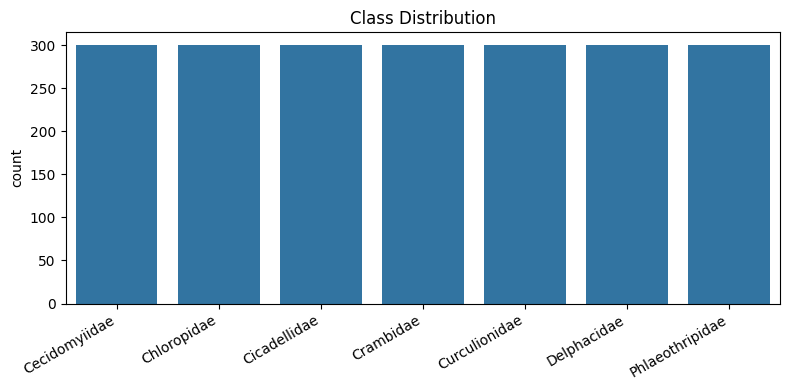

In [5]:
# Class distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=labels)
plt.xticks(ticks=range(NUM_CLASSES), labels=class_names, rotation=30, ha='right')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
2026-02-27

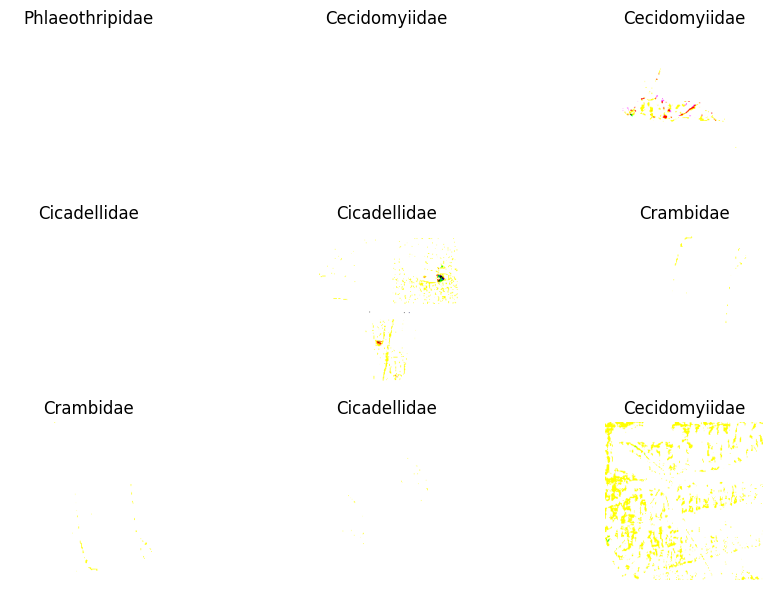

In [6]:
# Sample images
plt.figure(figsize=(10, 6))
for images, labels_batch in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label_idx = int(tf.argmax(labels_batch[i]).numpy())
        plt.title(class_names[label_idx])
        plt.axis('off')
plt.tight_layout()
plt.show()


In [7]:
# Model: Transfer learning with MobileNetV2
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Train
Path('models').mkdir(exist_ok=True)
checkpoint_path = 'models/best_model.keras'

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.6088 - loss: 1.1357 - val_accuracy: 0.8381 - val_loss: 0.5299
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8537 - loss: 0.4774 - val_accuracy: 0.8730 - val_loss: 0.4273
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8986 - loss: 0.3433 - val_accuracy: 0.8952 - val_loss: 0.3140
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9177 - loss: 0.2797 - val_accuracy: 0.9079 - val_loss: 0.2691
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9388 - loss: 0.2275 - val_accuracy: 0.9206 - val_loss: 0.2324
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9367 - loss: 0.2104 - val_accuracy: 0.9238 - val_loss: 0.2434
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9531 - loss: 0.1902 - val_accuracy: 0.9333 - val_loss: 0.2253
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9585 - loss: 0.1582 - val_accuracy: 0.9333 - 

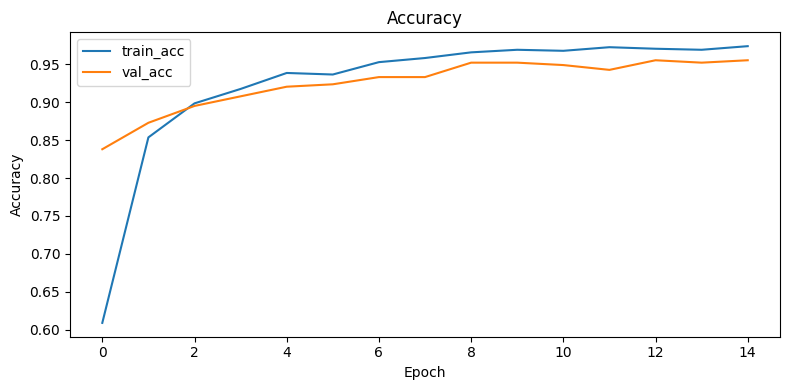

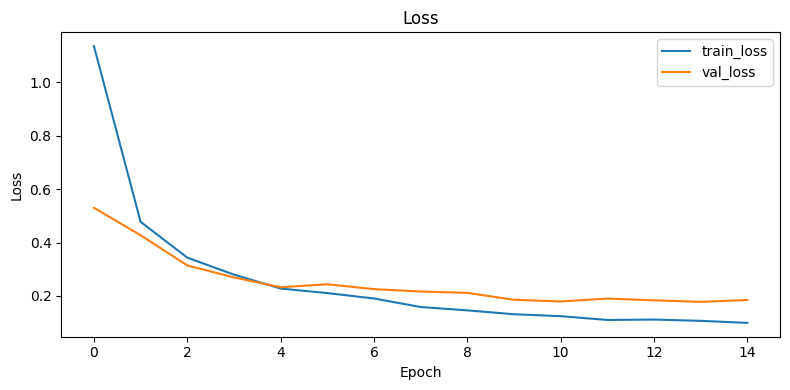

In [9]:
# Training curves
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9524 - loss: 0.1240
Test accuracy: 0.9524


2026-02-27 02:31:39.996230: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


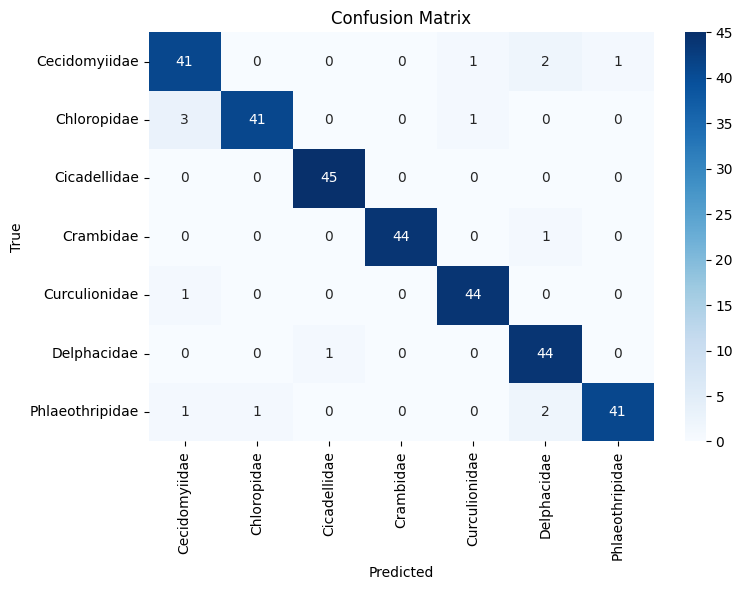

                 precision    recall  f1-score   support

  Cecidomyiidae       0.89      0.91      0.90        45
    Chloropidae       0.98      0.91      0.94        45
   Cicadellidae       0.98      1.00      0.99        45
      Crambidae       1.00      0.98      0.99        45
  Curculionidae       0.96      0.98      0.97        45
    Delphacidae       0.90      0.98      0.94        45
Phlaeothripidae       0.98      0.91      0.94        45

       accuracy                           0.95       315
      macro avg       0.95      0.95      0.95       315
   weighted avg       0.95      0.95      0.95       315



In [10]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.4f}')

# Predictions for confusion matrix and report
y_true = []
y_pred = []
for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


In [12]:
# Save final model
model.save('models/pest_classifier.h5')
print('Saved model to models/pest_classifier')


Saved model to models/pest_classifier
